# Money Flow and Whale Concentration Analysis

This notebook analyzes money flow patterns and whale concentration metrics for cryptocurrency trading using TUTUSDC data from Binance. 

## Key Concepts:
- **Money Flow**: Measures taker buying vs selling activity (inflow vs outflow)
- **Whale Accumulation**: High large order% + strong inflow = bullish momentum
- **Whale Distribution**: High large order% + strong outflow = weakening momentum
- **Concentration Metrics**: Measure whale dominance and market volatility potential

## Analysis Framework:
- **Concentration > 35**: High whale control, more price volatility
- **Concentration < 20**: Low whale control, more stable price

Large Order Detection Thresholds:
Volume Threshold (80th percentile): 1699900.200000 CELO
Quote Volume Threshold (85th percentile): 190823.20352150 BTC
Trades Threshold (75th percentile): 1857 trades

Large Order Statistics:
Total periods with large orders: 93
Percentage of periods with large orders: 18.60%
Average large order percentage (24h rolling): 17.97%
Maximum large order percentage: 83.33%

Recent Large Order Activity (last 10 periods):
              timestamp    close      volume  is_large_order  large_order_pct  \
490 2025-10-05 04:00:00  0.10631    699997.0           False        12.500000   
491 2025-10-05 05:00:00  0.12719  10665364.0            True        16.666667   
492 2025-10-05 06:00:00  0.13038   5946895.0            True        20.833333   
493 2025-10-05 07:00:00  0.10598  12117151.0            True        25.000000   
494 2025-10-05 08:00:00  0.10656   3924374.0            True        29.166667   
495 2025-10-05 09:00:00  0.10416   2812303.0            True     

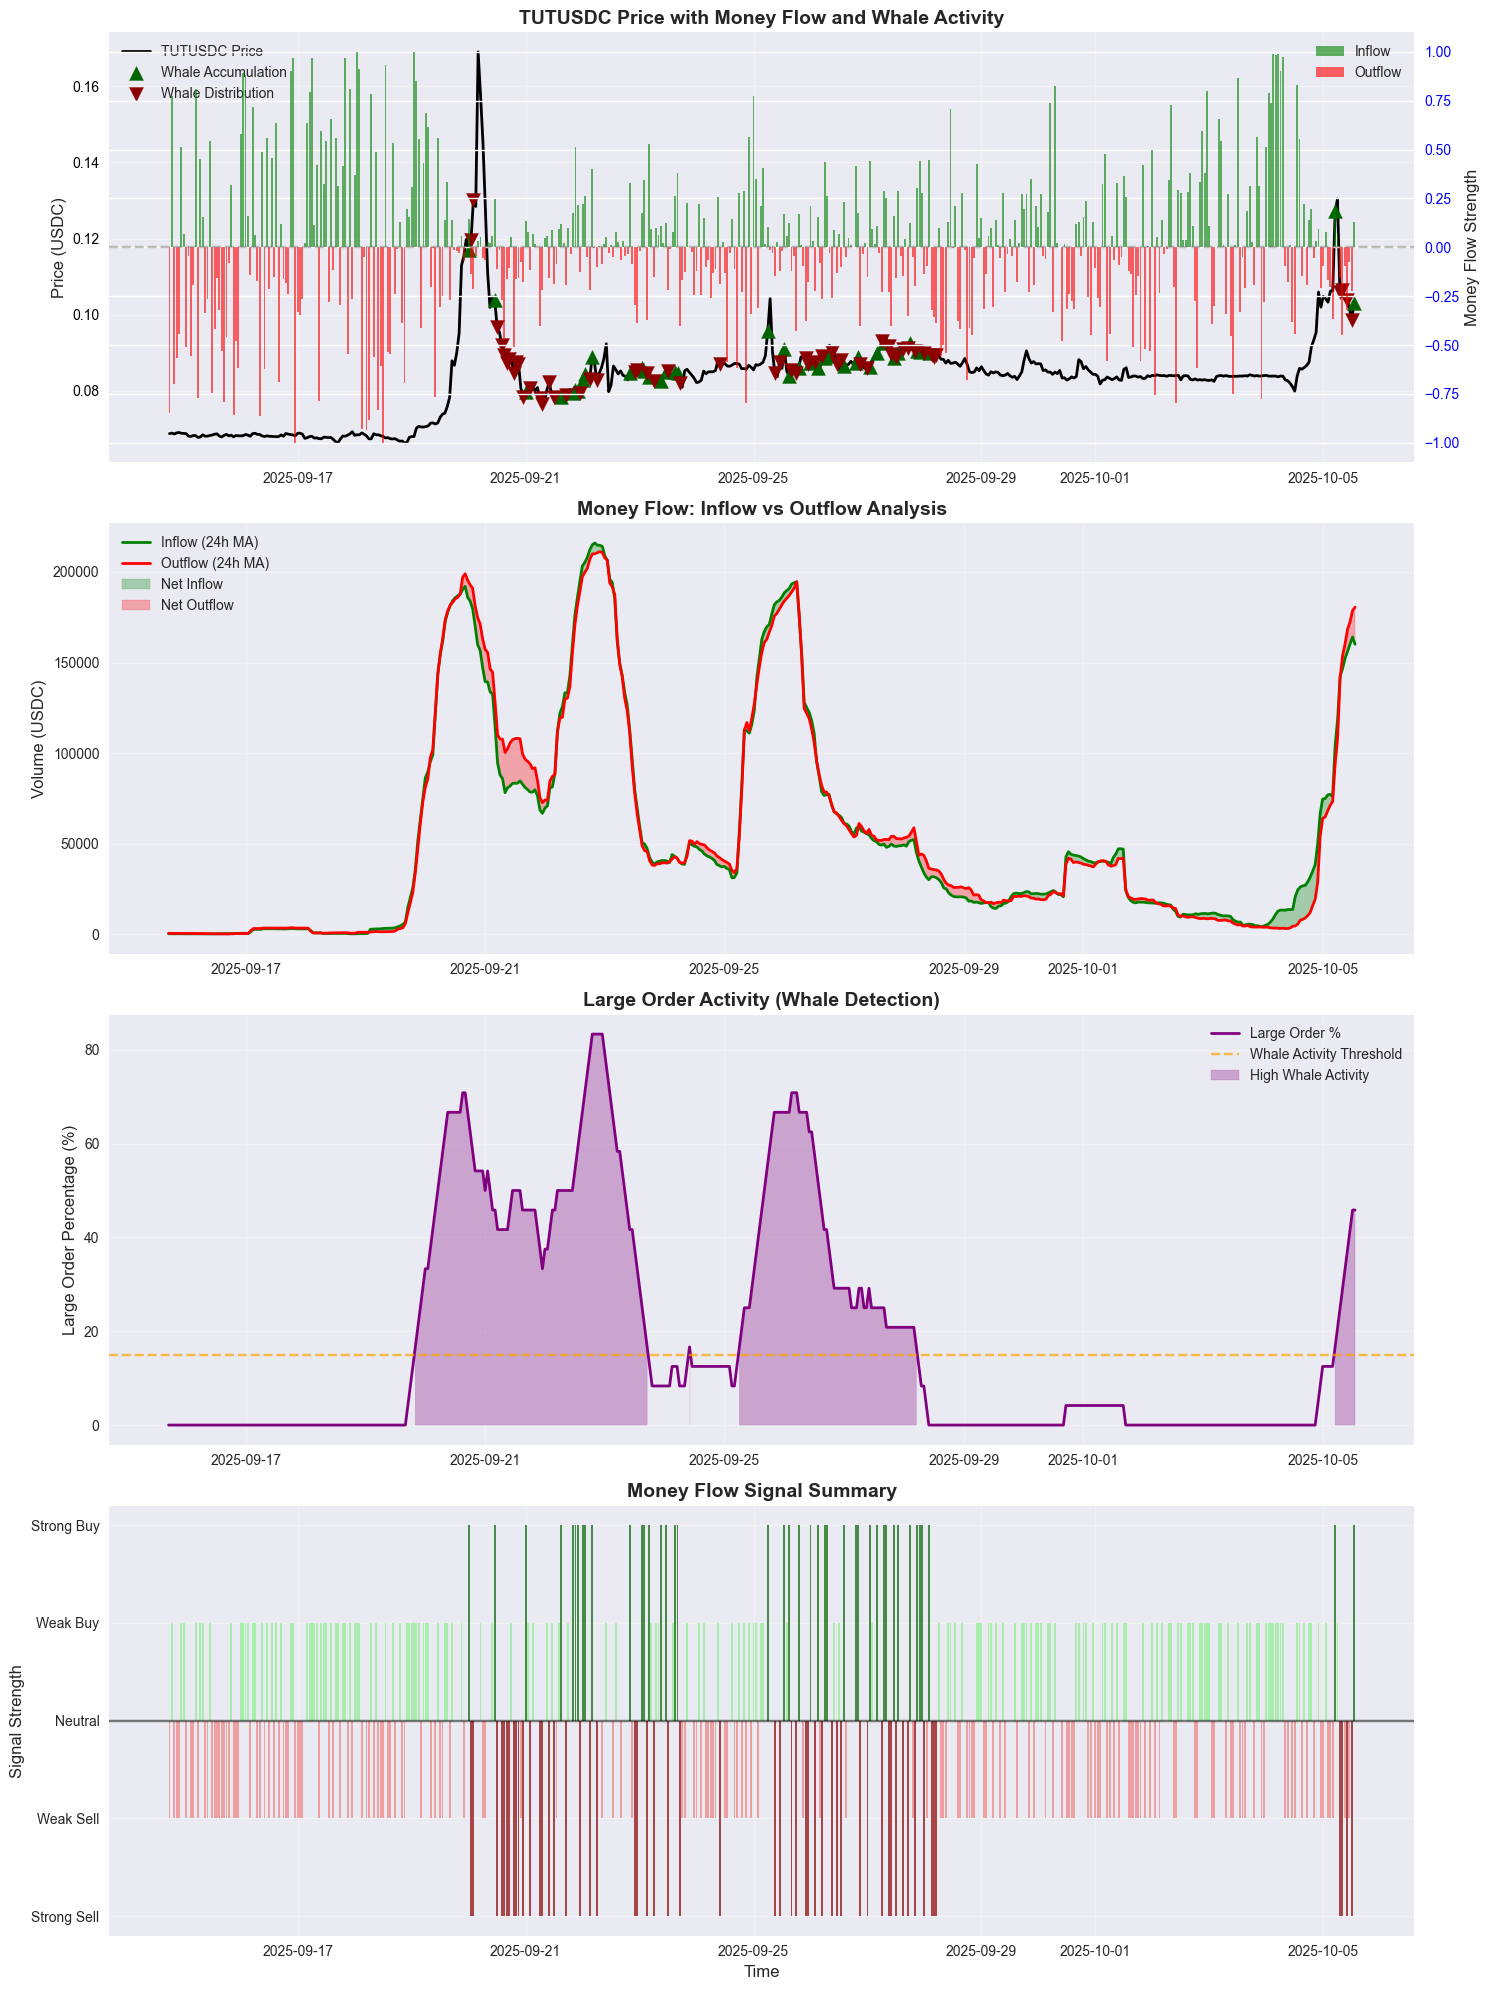

\nWhale Activity Summary:
Whale Accumulation signals: 42 periods
Whale Distribution signals: 55 periods
Strong bullish periods: 42
Strong bearish periods: 55


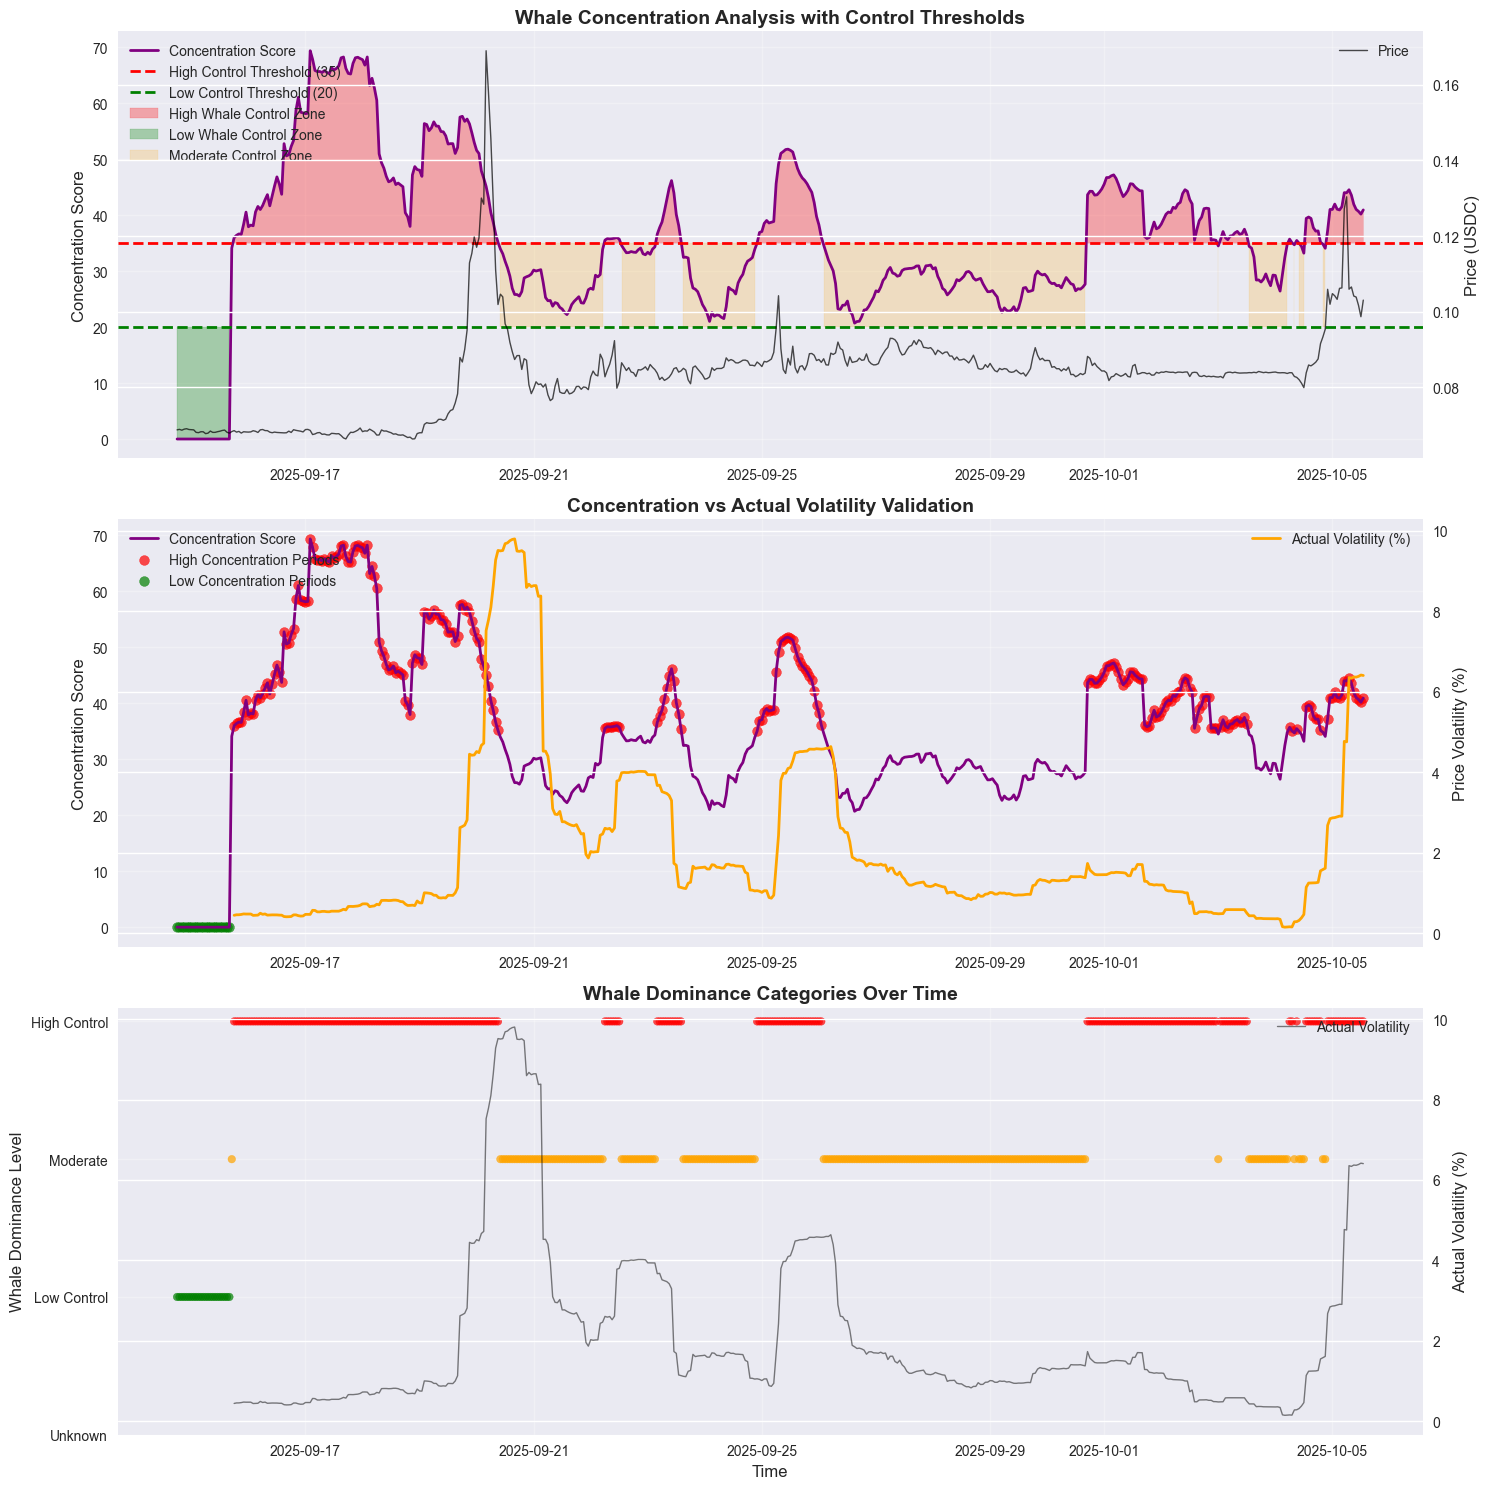

\nConcentration-Volatility Correlation: -0.145
Average volatility during high concentration: 1.795%
Average volatility during low concentration: nan%
Volatility difference: nan%
Creating comprehensive whale analysis dashboard...


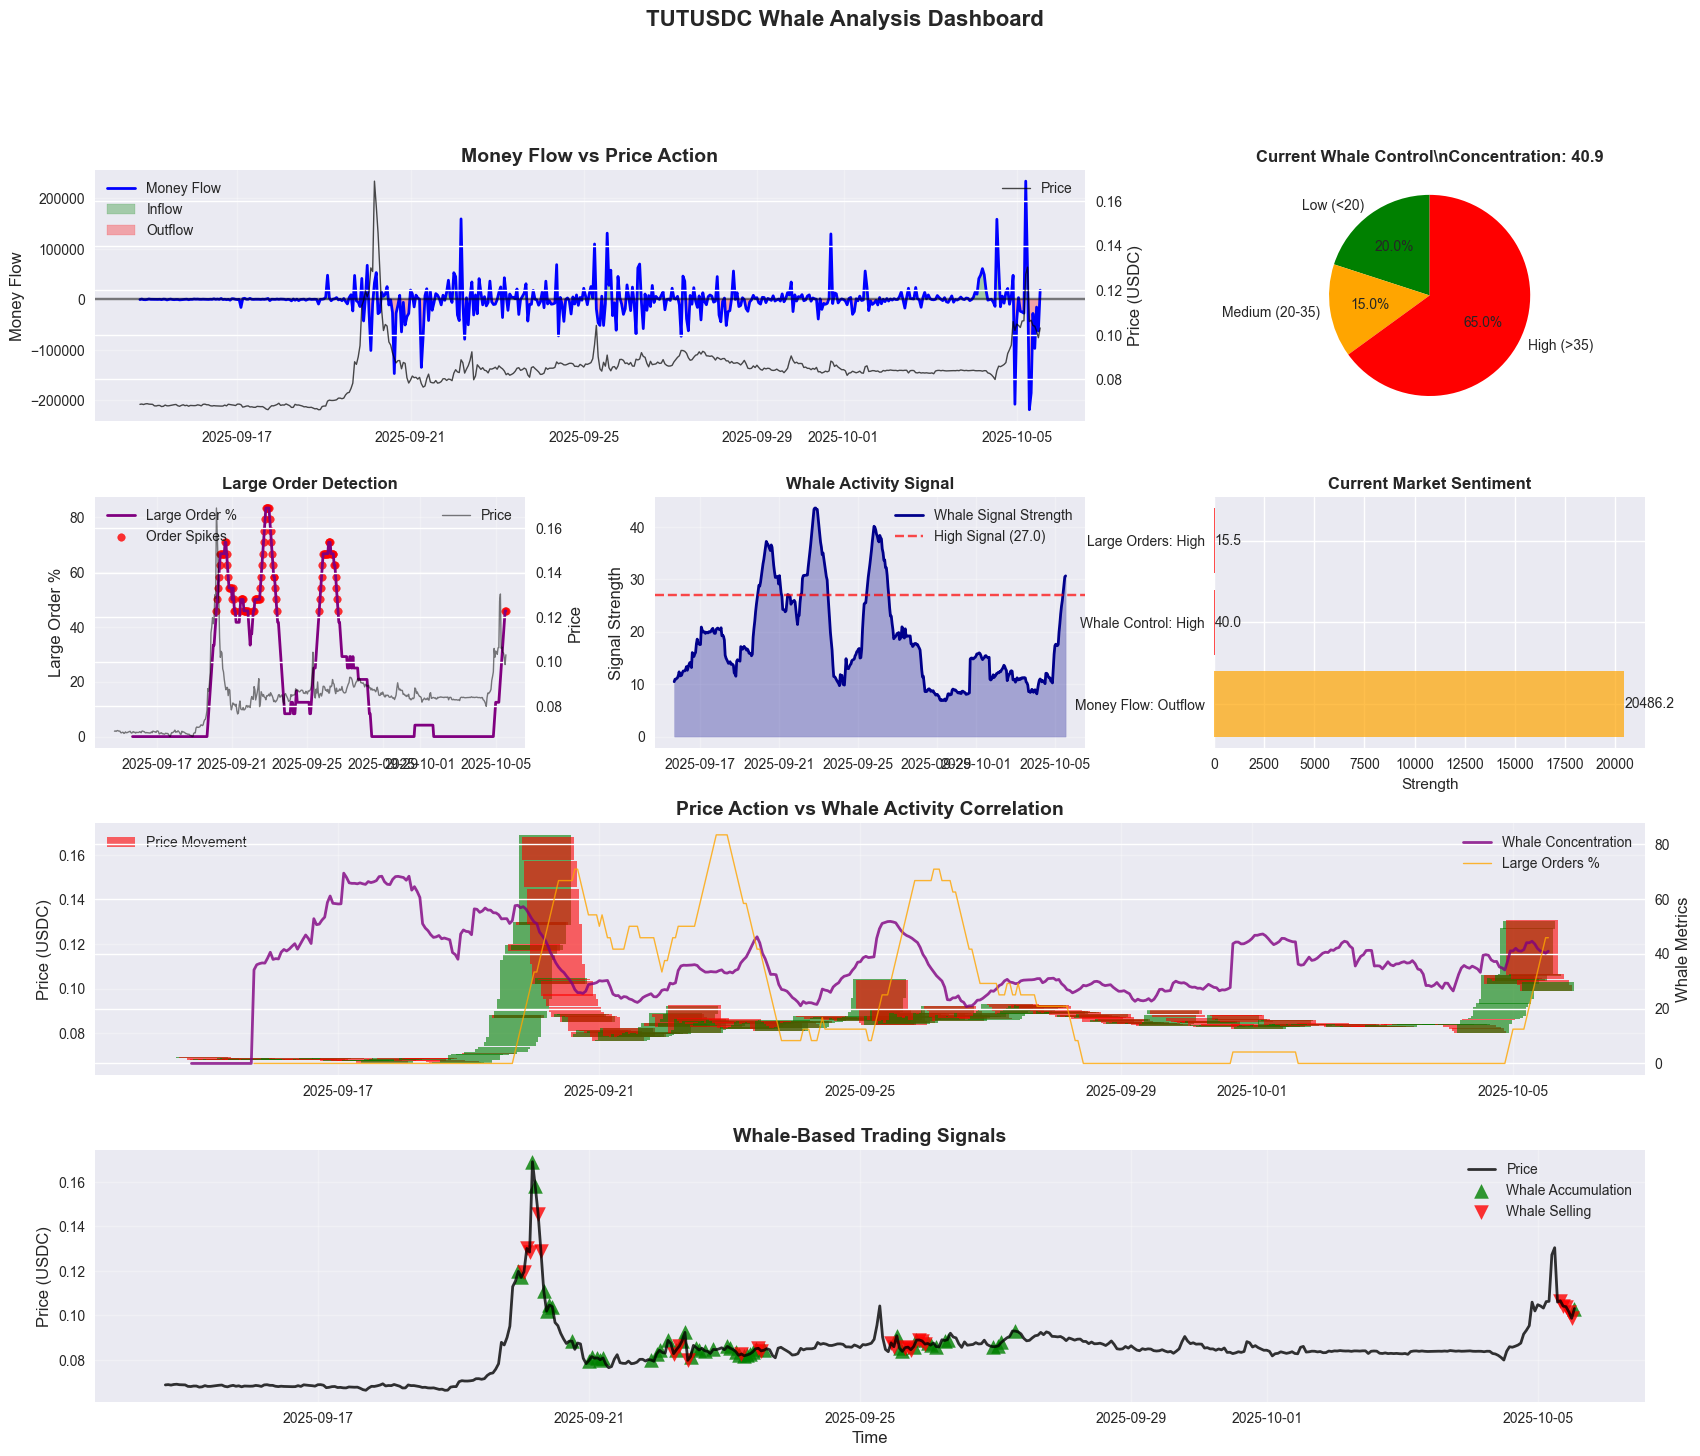

\n================================================================================
WHALE ANALYSIS SUMMARY
Analysis Period: 2025-09-14 18:00:00 to 2025-10-05 13:00:00
Total Data Points: 500

CURRENT MARKET STATE:
├─ Price: 0.10308000 USDC
├─ Money Flow: 18118.46 (INFLOW)
├─ Whale Concentration: 40.9
├─ Large Order %: 45.8%
└─ Whale Dominance: High Whale Control

WHALE ACTIVITY STATISTICS:
├─ Average Concentration: 35.9
├─ High Control Periods: 251 / 500 (50.2%)
├─ Low Control Periods: 23 / 500 (4.6%)
├─ Average Large Order %: 18.0%
└─ Money Flow Correlation with Price: -0.008

TRADING SIGNALS:
├─ Whale Accumulation Signals: 51
├─ Whale Selling Signals: 24
└─ Signal Ratio (Bull/Bear): 2.12
\n🐋 Whale Analysis Complete! 🐋
Use the insights above to understand whale behavior and market dynamics.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from typing import Optional
import seaborn as sns
from datetime import datetime, timedelta

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def fetch_binance_klines(symbol: str, interval: str = "15m", limit: int = 500, end_time: Optional[int] = None) -> pd.DataFrame:
    """Fetch klines from Binance REST API and return a standardized DataFrame.
    Columns: timestamp, open, high, low, close, volume, quote_asset_volume, taker_base, taker_quote, number_of_trades
    """
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    if not data:
        raise RuntimeError("Empty response from Binance")
    df = pd.DataFrame(data, columns=[
        "open_time","open","high","low","close","volume","close_time","quote_asset_volume",
        "number_of_trades","taker_base","taker_quote","ignore"
    ])
    num_cols = ["open","high","low","close","volume","quote_asset_volume","number_of_trades","taker_base","taker_quote"]
    df[num_cols] = df[num_cols].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    return df[["timestamp","open","high","low","close","volume","quote_asset_volume","taker_base","taker_quote","number_of_trades"]].sort_values("timestamp").reset_index(drop=True)


def calculate_money_flow_indicators(df):
    """
    Calculate money flow indicators based on taker buying vs selling activity.
    
    Key Concepts:
    - Taker Base Volume (taker_base): Volume of taker buy orders (buying pressure)
    - Taker Quote Volume (taker_quote): Quote asset volume of taker buy orders
    - Total Inflow: Money flowing into the asset (taker buying)
    - Total Outflow: Money flowing out of the asset (taker selling)
    """
    df = df.copy()
    
    # Calculate inflow and outflow based on taker activity
    # Inflow: Taker buy orders (quote volume spent on buying)
    df['inflow'] = df['taker_quote']  # USDC spent on buying TUTU
    
    # Outflow: Taker sell orders (quote volume received from selling)
    df['outflow'] = df['quote_asset_volume'] - df['taker_quote']  # USDC received from selling TUTU
    
    # Net money flow (positive = net buying, negative = net selling)
    df['net_money_flow'] = df['inflow'] - df['outflow']
    
    # Money flow ratio (> 1 = more buying, < 1 = more selling)
    df['money_flow_ratio'] = df['inflow'] / (df['outflow'] + 1e-10)  # Avoid division by zero
    
    # Taker buy ratio (percentage of volume that was taker buys)
    df['taker_buy_ratio'] = df['taker_base'] / (df['volume'] + 1e-10)
    
    # Money flow strength (normalized between -1 and 1)
    df['money_flow_strength'] = (df['inflow'] - df['outflow']) / (df['inflow'] + df['outflow'] + 1e-10)
    
    # Rolling averages for trend analysis
    window = 24  # 24 hours for 1h intervals
    df['inflow_ma'] = df['inflow'].rolling(window).mean()
    df['outflow_ma'] = df['outflow'].rolling(window).mean()
    df['net_flow_ma'] = df['net_money_flow'].rolling(window).mean()
    df['money_flow_trend'] = df['net_flow_ma'].rolling(12).apply(lambda x: 1 if x.iloc[-1] > x.iloc[0] else -1, raw=False)
    
    return df

def detect_large_orders(df, volume_threshold_percentile=80, quote_threshold_percentile=85):
    """
    Detect large orders based on volume and quote volume thresholds.
    
    Large orders are identified by:
    1. Volume exceeding a certain percentile
    2. Quote volume exceeding a certain percentile
    3. High number of trades (indicating institutional activity)
    """
    df = df.copy()
    
    # Calculate thresholds
    volume_threshold = df['volume'].quantile(volume_threshold_percentile / 100)
    quote_threshold = df['quote_asset_volume'].quantile(quote_threshold_percentile / 100)
    trades_threshold = df['number_of_trades'].quantile(0.75)
    
    # Identify large orders
    df['is_large_volume'] = df['volume'] >= volume_threshold
    df['is_large_quote'] = df['quote_asset_volume'] >= quote_threshold
    df['is_high_trades'] = df['number_of_trades'] >= trades_threshold
    
    # Combined large order flag
    df['is_large_order'] = (df['is_large_volume'] | df['is_large_quote']) & df['is_high_trades']
    
    # Calculate large order percentage in rolling window
    window = 24  # 24-hour window for 1h intervals
    df['large_order_pct'] = df['is_large_order'].rolling(window).mean() * 100
    
    # Volume-weighted indicators
    df['avg_trade_size'] = df['volume'] / (df['number_of_trades'] + 1e-10)
    df['avg_trade_value'] = df['quote_asset_volume'] / (df['number_of_trades'] + 1e-10)
    
    # Large order intensity (combining size and frequency)
    df['large_order_intensity'] = (
        df['large_order_pct'] * 
        (df['avg_trade_value'] / df['avg_trade_value'].rolling(window).mean()).fillna(1)
    )
    
    print(f"Large Order Detection Thresholds:")
    print(f"Volume Threshold ({volume_threshold_percentile}th percentile): {volume_threshold:.6f} CELO")
    print(f"Quote Volume Threshold ({quote_threshold_percentile}th percentile): {quote_threshold:.8f} BTC")
    print(f"Trades Threshold (75th percentile): {trades_threshold:.0f} trades")
    
    return df

# Fetch TUTUSDC data with higher limit for better analysis
symbol = "TUTUSDC"
interval = "1h"  # 1-hour intervals for whale activity analysis
limit = 500  # Get more data points for pattern analysis

df = fetch_binance_klines(symbol, interval=interval, limit=limit)
# Apply money flow calculations
df = calculate_money_flow_indicators(df)

# Apply large order detection
df = detect_large_orders(df)

# Display large order statistics
large_order_periods = df[df['is_large_order'] == True]
print(f"\nLarge Order Statistics:")
print(f"Total periods with large orders: {len(large_order_periods)}")
print(f"Percentage of periods with large orders: {len(large_order_periods)/len(df)*100:.2f}%")
print(f"Average large order percentage (24h rolling): {df['large_order_pct'].mean():.2f}%")
print(f"Maximum large order percentage: {df['large_order_pct'].max():.2f}%")

# Show recent large order data
print(f"\nRecent Large Order Activity (last 10 periods):")
large_order_cols = ['timestamp', 'close', 'volume', 'is_large_order', 'large_order_pct', 'large_order_intensity']
print(df[large_order_cols].tail(10))


def detect_large_orders(df, volume_threshold_percentile=80, quote_threshold_percentile=85):
    """
    Detect large orders based on volume and quote volume thresholds.
    
    Large orders are identified by:
    1. Volume exceeding a certain percentile
    2. Quote volume exceeding a certain percentile
    3. High number of trades (indicating institutional activity)
    """
    df = df.copy()
    
    # Calculate thresholds
    volume_threshold = df['volume'].quantile(volume_threshold_percentile / 100)
    quote_threshold = df['quote_asset_volume'].quantile(quote_threshold_percentile / 100)
    trades_threshold = df['number_of_trades'].quantile(0.75)
    
    # Identify large orders
    df['is_large_volume'] = df['volume'] >= volume_threshold
    df['is_large_quote'] = df['quote_asset_volume'] >= quote_threshold
    df['is_high_trades'] = df['number_of_trades'] >= trades_threshold
    
    # Combined large order flag
    df['is_large_order'] = (df['is_large_volume'] | df['is_large_quote']) & df['is_high_trades']
    
    # Calculate large order percentage in rolling window
    window = 24  # 24-hour window for 1h intervals
    df['large_order_pct'] = df['is_large_order'].rolling(window).mean() * 100
    
    # Volume-weighted indicators
    df['avg_trade_size'] = df['volume'] / (df['number_of_trades'] + 1e-10)
    df['avg_trade_value'] = df['quote_asset_volume'] / (df['number_of_trades'] + 1e-10)
    
    # Large order intensity (combining size and frequency)
    df['large_order_intensity'] = (
        df['large_order_pct'] * 
        (df['avg_trade_value'] / df['avg_trade_value'].rolling(window).mean()).fillna(1)
    )
    
    print(f"Large Order Detection Thresholds:")
    print(f"Volume Threshold ({volume_threshold_percentile}th percentile): {volume_threshold:.6f} TUTU")
    print(f"Quote Volume Threshold ({quote_threshold_percentile}th percentile): {quote_threshold:.8f} USDC")
    print(f"Trades Threshold (75th percentile): {trades_threshold:.0f} trades")
    
    return df

# Apply large order detection
df = detect_large_orders(df)

# Display large order statistics
large_order_periods = df[df['is_large_order'] == True]
print(f"\nLarge Order Statistics:")
print(f"Total periods with large orders: {len(large_order_periods)}")
print(f"Percentage of periods with large orders: {len(large_order_periods)/len(df)*100:.2f}%")
print(f"Average large order percentage (24h rolling): {df['large_order_pct'].mean():.2f}%")
print(f"Maximum large order percentage: {df['large_order_pct'].max():.2f}%")

# Show recent large order data
print(f"\nRecent Large Order Activity (last 10 periods):")
large_order_cols = ['timestamp', 'close', 'volume', 'is_large_order', 'large_order_pct', 'large_order_intensity']
print(df[large_order_cols].tail(10))

def calculate_concentration_metrics(df, window=24):
    """
    Calculate whale concentration metrics to measure market dominance.
    
    Concentration measures:
    1. Volume concentration: How much volume is concentrated in large orders
    2. Trade size concentration: Distribution of trade sizes
    3. Time concentration: Clustering of large orders in time
    4. Overall concentration score
    
    Thresholds:
    - Concentration > 35: High whale control, more volatility
    - Concentration < 20: Low whale control, more stability
    """
    df = df.copy()
    
    # 1. Volume Concentration (Gini coefficient for volume distribution)
    def gini_coefficient(x):
        """Calculate Gini coefficient for concentration measurement"""
        x = np.array(x)
        x = x[x > 0]  # Remove zero values
        if len(x) == 0:
            return 0
        x = np.sort(x)
        n = len(x)
        cumsum = np.cumsum(x)
        return (2 * np.sum((np.arange(1, n + 1) * x))) / (n * cumsum[-1]) - (n + 1) / n
    
    # Rolling Gini coefficient for volume concentration
    df['volume_concentration'] = df['volume'].rolling(window).apply(
        lambda x: gini_coefficient(x) * 100, raw=True
    )
    
    # 2. Trade Size Concentration
    df['trade_size_variance'] = (
        df['avg_trade_size'].rolling(window).std() / 
        (df['avg_trade_size'].rolling(window).mean() + 1e-10)
    ) * 100
    
    # 3. Large Order Clustering (time concentration)
    df['large_order_clustering'] = df['large_order_pct'].rolling(window//2).std() * 2
    
    # 4. Quote Volume Concentration
    df['quote_concentration'] = df['quote_asset_volume'].rolling(window).apply(
        lambda x: gini_coefficient(x) * 100, raw=True
    )
    
    # 5. Overall Concentration Score (weighted combination)
    weights = {
        'volume': 0.3,
        'trade_size': 0.2,
        'clustering': 0.25,
        'quote': 0.25
    }
    
    df['concentration_score'] = (
        weights['volume'] * df['volume_concentration'].fillna(0) +
        weights['trade_size'] * df['trade_size_variance'].fillna(0) +
        weights['clustering'] * df['large_order_clustering'].fillna(0) +
        weights['quote'] * df['quote_concentration'].fillna(0)
    )
    
    # 6. Whale Dominance Categories
    def categorize_concentration(score):
        if pd.isna(score):
            return 'Unknown'
        elif score > 35:
            return 'High Whale Control'
        elif score < 20:
            return 'Low Whale Control'
        else:
            return 'Moderate Control'
    
    df['whale_dominance'] = df['concentration_score'].apply(categorize_concentration)
    
    # 7. Market Volatility Prediction based on concentration
    df['volatility_prediction'] = df['concentration_score'].apply(
        lambda x: 'High Volatility Expected' if pd.notna(x) and x > 35 
        else 'Low Volatility Expected' if pd.notna(x) and x < 20 
        else 'Moderate Volatility Expected'
    )
    
    return df

# Apply concentration calculations
df = calculate_concentration_metrics(df)

# Display concentration statistics
print("Whale Concentration Analysis:")
print(f"Average Concentration Score: {df['concentration_score'].mean():.2f}")
print(f"Maximum Concentration Score: {df['concentration_score'].max():.2f}")
print(f"Minimum Concentration Score: {df['concentration_score'].min():.2f}")

# Concentration distribution
concentration_dist = df['whale_dominance'].value_counts()
print(f"\nWhale Dominance Distribution:")
for category, count in concentration_dist.items():
    percentage = count / len(df) * 100
    print(f"{category}: {count} periods ({percentage:.1f}%)")

# Recent concentration data
print(f"\nRecent Concentration Metrics (last 5 periods):")
concentration_cols = ['timestamp', 'close', 'concentration_score', 'whale_dominance', 'volatility_prediction']
print(df[concentration_cols].tail())


def create_money_flow_charts(df):
    """Create comprehensive money flow visualization"""
    
    # Identify whale accumulation and distribution signals
    df['whale_accumulation'] = (df['large_order_pct'] > 15) & (df['money_flow_strength'] > 0.1)
    df['whale_distribution'] = (df['large_order_pct'] > 15) & (df['money_flow_strength'] < -0.1)
    
    fig, axes = plt.subplots(4, 1, figsize=(15, 20))
    
    # 1. Price and Money Flow
    ax1 = axes[0]
    ax1_twin = ax1.twinx()
    
    # Price line
    ax1.plot(df['timestamp'], df['close'], color='black', linewidth=2, label='TUTUSDC Price')
    ax1.set_ylabel('Price (USDC)', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='black')
    
    # Money flow strength
    positive_flow = df['money_flow_strength'] >= 0
    ax1_twin.bar(df['timestamp'][positive_flow], df['money_flow_strength'][positive_flow], 
                color='green', alpha=0.6, width=pd.Timedelta(hours=0.8), label='Inflow')
    ax1_twin.bar(df['timestamp'][~positive_flow], df['money_flow_strength'][~positive_flow], 
                color='red', alpha=0.6, width=pd.Timedelta(hours=0.8), label='Outflow')
    ax1_twin.set_ylabel('Money Flow Strength', fontsize=12)
    ax1_twin.tick_params(axis='y', labelcolor='blue')
    ax1_twin.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Mark whale signals
    whale_acc = df[df['whale_accumulation']]
    whale_dist = df[df['whale_distribution']]
    
    if len(whale_acc) > 0:
        ax1.scatter(whale_acc['timestamp'], whale_acc['close'], 
                   color='darkgreen', s=100, marker='^', 
                   label='Whale Accumulation', zorder=5)
    
    if len(whale_dist) > 0:
        ax1.scatter(whale_dist['timestamp'], whale_dist['close'], 
                   color='darkred', s=100, marker='v', 
                   label='Whale Distribution', zorder=5)
    
    ax1.set_title('TUTUSDC Price with Money Flow and Whale Activity', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Inflow vs Outflow
    ax2 = axes[1]
    ax2.plot(df['timestamp'], df['inflow_ma'], color='green', linewidth=2, label='Inflow (24h MA)')
    ax2.plot(df['timestamp'], df['outflow_ma'], color='red', linewidth=2, label='Outflow (24h MA)')
    ax2.fill_between(df['timestamp'], df['inflow_ma'], df['outflow_ma'], 
                     where=(df['inflow_ma'] >= df['outflow_ma']), 
                     color='green', alpha=0.3, interpolate=True, label='Net Inflow')
    ax2.fill_between(df['timestamp'], df['inflow_ma'], df['outflow_ma'], 
                     where=(df['inflow_ma'] < df['outflow_ma']), 
                     color='red', alpha=0.3, interpolate=True, label='Net Outflow')
    
    ax2.set_ylabel('Volume (USDC)', fontsize=12)
    ax2.set_title('Money Flow: Inflow vs Outflow Analysis', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Large Order Activity
    ax3 = axes[2]
    ax3.plot(df['timestamp'], df['large_order_pct'], color='purple', linewidth=2, label='Large Order %')
    ax3.axhline(y=15, color='orange', linestyle='--', alpha=0.7, label='Whale Activity Threshold')
    ax3.fill_between(df['timestamp'], 0, df['large_order_pct'], 
                     where=(df['large_order_pct'] > 15), 
                     color='purple', alpha=0.3, label='High Whale Activity')
    
    ax3.set_ylabel('Large Order Percentage (%)', fontsize=12)
    ax3.set_title('Large Order Activity (Whale Detection)', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Money Flow Signals Summary
    ax4 = axes[3]
    
    # Create signal strength indicator
    signal_strength = np.zeros(len(df))
    signal_strength[df['whale_accumulation']] = 2  # Strong bullish
    signal_strength[df['whale_distribution']] = -2  # Strong bearish
    signal_strength[(df['money_flow_strength'] > 0.05) & (~df['whale_accumulation'])] = 1  # Moderate bullish
    signal_strength[(df['money_flow_strength'] < -0.05) & (~df['whale_distribution'])] = -1  # Moderate bearish
    
    colors = []
    for val in signal_strength:
        if val == 2:
            colors.append('darkgreen')
        elif val == 1:
            colors.append('lightgreen')
        elif val == -1:
            colors.append('lightcoral')
        elif val == -2:
            colors.append('darkred')
        else:
            colors.append('lightgray')
    
    ax4.bar(df['timestamp'], signal_strength, color=colors, alpha=0.7, width=pd.Timedelta(hours=0.8))
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax4.set_ylabel('Signal Strength', fontsize=12)
    ax4.set_xlabel('Time', fontsize=12)
    ax4.set_title('Money Flow Signal Summary', fontsize=14, fontweight='bold')
    ax4.set_yticks([-2, -1, 0, 1, 2])
    ax4.set_yticklabels(['Strong Sell', 'Weak Sell', 'Neutral', 'Weak Buy', 'Strong Buy'])
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print signal summary
    print("\\nWhale Activity Summary:")
    print(f"Whale Accumulation signals: {sum(df['whale_accumulation'])} periods")
    print(f"Whale Distribution signals: {sum(df['whale_distribution'])} periods")
    print(f"Strong bullish periods: {sum(signal_strength == 2)}")
    print(f"Strong bearish periods: {sum(signal_strength == -2)}")
    
    return df

# Create money flow charts
df = create_money_flow_charts(df)

def create_whale_concentration_analysis(df):
    """Create whale concentration analysis with volatility predictions"""
    
    # Calculate actual volatility for validation
    df['price_volatility'] = df['close'].pct_change().rolling(24).std() * 100
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    
    # 1. Concentration Score with Thresholds
    ax1 = axes[0]
    ax1_twin = ax1.twinx()
    
    # Plot concentration score
    ax1.plot(df['timestamp'], df['concentration_score'], color='purple', linewidth=2, label='Concentration Score')
    ax1.axhline(y=35, color='red', linestyle='--', linewidth=2, label='High Control Threshold (35)')
    ax1.axhline(y=20, color='green', linestyle='--', linewidth=2, label='Low Control Threshold (20)')
    
    # Fill areas for different control levels
    ax1.fill_between(df['timestamp'], 35, df['concentration_score'], 
                     where=(df['concentration_score'] > 35), 
                     color='red', alpha=0.3, label='High Whale Control Zone')
    ax1.fill_between(df['timestamp'], 20, df['concentration_score'], 
                     where=(df['concentration_score'] < 20), 
                     color='green', alpha=0.3, label='Low Whale Control Zone')
    ax1.fill_between(df['timestamp'], 20, 35, 
                     where=((df['concentration_score'] >= 20) & (df['concentration_score'] <= 35)), 
                     color='orange', alpha=0.2, label='Moderate Control Zone')
    
    # Price on secondary axis
    ax1_twin.plot(df['timestamp'], df['close'], color='black', linewidth=1, alpha=0.7, label='Price')
    ax1_twin.set_ylabel('Price (USDC)', fontsize=12)
    
    ax1.set_ylabel('Concentration Score', fontsize=12)
    ax1.set_title('Whale Concentration Analysis with Control Thresholds', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Concentration vs Volatility Validation
    ax2 = axes[1]
    
    # Plot both concentration and actual volatility
    ax2_twin = ax2.twinx()
    
    ax2.plot(df['timestamp'], df['concentration_score'], color='purple', linewidth=2, label='Concentration Score')
    ax2_twin.plot(df['timestamp'], df['price_volatility'], color='orange', linewidth=2, label='Actual Volatility (%)')
    
    # Mark high concentration periods
    high_concentration = df['concentration_score'] > 35
    low_concentration = df['concentration_score'] < 20
    
    if high_concentration.any():
        high_conc_periods = df[high_concentration]
        ax2.scatter(high_conc_periods['timestamp'], high_conc_periods['concentration_score'], 
                   color='red', s=50, alpha=0.7, label='High Concentration Periods')
    
    if low_concentration.any():
        low_conc_periods = df[low_concentration]
        ax2.scatter(low_conc_periods['timestamp'], low_conc_periods['concentration_score'], 
                   color='green', s=50, alpha=0.7, label='Low Concentration Periods')
    
    ax2.set_ylabel('Concentration Score', fontsize=12)
    ax2_twin.set_ylabel('Price Volatility (%)', fontsize=12)
    ax2.set_title('Concentration vs Actual Volatility Validation', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left')
    ax2_twin.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # 3. Whale Dominance Categories
    ax3 = axes[2]
    
    # Create categorical plot
    dominance_mapping = {'High Whale Control': 3, 'Moderate Control': 2, 'Low Whale Control': 1, 'Unknown': 0}
    dominance_numeric = df['whale_dominance'].map(dominance_mapping)
    
    colors_map = {3: 'red', 2: 'orange', 1: 'green', 0: 'gray'}
    colors = [colors_map[val] for val in dominance_numeric]
    
    ax3.scatter(df['timestamp'], dominance_numeric, c=colors, alpha=0.7, s=30)
    ax3.set_ylabel('Whale Dominance Level', fontsize=12)
    ax3.set_xlabel('Time', fontsize=12)
    ax3.set_yticks([0, 1, 2, 3])
    ax3.set_yticklabels(['Unknown', 'Low Control', 'Moderate', 'High Control'])
    ax3.set_title('Whale Dominance Categories Over Time', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add volatility prediction accuracy
    ax3_twin = ax3.twinx()
    ax3_twin.plot(df['timestamp'], df['price_volatility'], color='black', linewidth=1, alpha=0.5, label='Actual Volatility')
    ax3_twin.set_ylabel('Actual Volatility (%)', fontsize=12)
    ax3_twin.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Correlation analysis
    valid_data = df.dropna(subset=['concentration_score', 'price_volatility'])
    if len(valid_data) > 10:
        correlation = valid_data['concentration_score'].corr(valid_data['price_volatility'])
        print(f"\\nConcentration-Volatility Correlation: {correlation:.3f}")
        
        # Validate predictions
        high_conc_volatility = valid_data[valid_data['concentration_score'] > 35]['price_volatility'].mean()
        low_conc_volatility = valid_data[valid_data['concentration_score'] < 20]['price_volatility'].mean()
        
        print(f"Average volatility during high concentration: {high_conc_volatility:.3f}%")
        print(f"Average volatility during low concentration: {low_conc_volatility:.3f}%")
        print(f"Volatility difference: {high_conc_volatility - low_conc_volatility:.3f}%")
    
    return df

# Create whale concentration analysis
df = create_whale_concentration_analysis(df)

def create_combined_analysis_dashboard(df):
    """Create comprehensive dashboard combining all analysis components"""
    
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    # 1. Money Flow Overview (Top Row - Spans 2 columns)
    ax1 = fig.add_subplot(gs[0, :2])
    ax1_twin = ax1.twinx()
    
    # Money flow on primary axis
    ax1.plot(df['timestamp'], df['net_money_flow'], color='blue', linewidth=2, label='Money Flow')
    ax1.fill_between(df['timestamp'], 0, df['net_money_flow'], 
                     where=(df['net_money_flow'] > 0), color='green', alpha=0.3, label='Inflow')
    ax1.fill_between(df['timestamp'], 0, df['net_money_flow'], 
                     where=(df['net_money_flow'] < 0), color='red', alpha=0.3, label='Outflow')
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Price on secondary axis
    ax1_twin.plot(df['timestamp'], df['close'], color='black', linewidth=1, alpha=0.7, label='Price')
    
    ax1.set_ylabel('Money Flow', fontsize=12)
    ax1_twin.set_ylabel('Price (USDC)', fontsize=12)
    ax1.set_title('Money Flow vs Price Action', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Whale Concentration (Top Right)
    ax2 = fig.add_subplot(gs[0, 2])
    
    # Concentration gauge
    current_concentration = df['concentration_score'].iloc[-1]
    colors = ['green', 'orange', 'red']
    labels = ['Low (<20)', 'Medium (20-35)', 'High (>35)']
    
    if current_concentration < 20:
        highlight = [1, 0.3, 0.3]
    elif current_concentration < 35:
        highlight = [0.3, 1, 0.3]
    else:
        highlight = [0.3, 0.3, 1]
    
    ax2.pie([20, 15, 100-35], labels=labels, colors=[c for c, h in zip(colors, highlight)], 
            autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'Current Whale Control\\nConcentration: {current_concentration:.1f}', 
                  fontsize=12, fontweight='bold')
    
    # 3. Large Orders Detection (Second Row - Left)
    ax3 = fig.add_subplot(gs[1, 0])
    ax3_twin = ax3.twinx()
    
    ax3.plot(df['timestamp'], df['large_order_pct'], color='purple', linewidth=2, label='Large Order %')
    ax3_twin.plot(df['timestamp'], df['close'], color='black', linewidth=1, alpha=0.5, label='Price')
    
    # Highlight large order spikes
    large_spikes = df['large_order_pct'] > df['large_order_pct'].quantile(0.8)
    if large_spikes.any():
        spike_data = df[large_spikes]
        ax3.scatter(spike_data['timestamp'], spike_data['large_order_pct'], 
                   color='red', s=30, alpha=0.8, label='Order Spikes')
    
    ax3.set_ylabel('Large Order %', fontsize=12)
    ax3_twin.set_ylabel('Price', fontsize=12)
    ax3.set_title('Large Order Detection', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper left')
    ax3_twin.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)
    
    # 4. Whale Signals (Second Row - Middle)
    ax4 = fig.add_subplot(gs[1, 1])
    
    # Create whale signal strength indicator
    signal_strength = (df['large_order_pct'] * 0.4 + 
                      abs(df['money_flow_strength']) * 0.3 + 
                      df['concentration_score'] * 0.3)
    
    ax4.plot(df['timestamp'], signal_strength, color='darkblue', linewidth=2, label='Whale Signal Strength')
    ax4.fill_between(df['timestamp'], 0, signal_strength, alpha=0.3, color='darkblue')
    
    # Add threshold lines
    high_threshold = signal_strength.quantile(0.8)
    ax4.axhline(y=high_threshold, color='red', linestyle='--', alpha=0.7, label=f'High Signal ({high_threshold:.1f})')
    
    ax4.set_ylabel('Signal Strength', fontsize=12)
    ax4.set_title('Whale Activity Signal', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Market Sentiment Matrix (Second Row - Right)
    ax5 = fig.add_subplot(gs[1, 2])
    
    # Create sentiment categories
    recent_data = df.tail(24)  # Last 24 periods
    avg_flow = recent_data['net_money_flow'].mean()
    avg_concentration = recent_data['concentration_score'].mean()
    avg_large_orders = recent_data['large_order_pct'].mean()
    
    sentiment_data = {
        'Money Flow': ['Outflow' if avg_flow < 0 else 'Inflow', abs(avg_flow)],
        'Whale Control': ['High' if avg_concentration > 35 else 'Low' if avg_concentration < 20 else 'Medium', avg_concentration],
        'Large Orders': ['High' if avg_large_orders > 15 else 'Low', avg_large_orders],
    }
    
    y_pos = range(len(sentiment_data))
    values = [data[1] for data in sentiment_data.values()]
    labels = [f"{key}: {data[0]}" for key, data in sentiment_data.items()]
    colors = ['green' if 'Inflow' in label or 'Low' in label else 'red' if 'High' in label else 'orange' for label in labels]
    
    bars = ax5.barh(y_pos, values, color=colors, alpha=0.7)
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels(labels)
    ax5.set_xlabel('Strength')
    ax5.set_title('Current Market Sentiment', fontsize=12, fontweight='bold')
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, values)):
        ax5.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{value:.1f}', va='center', fontsize=10)
    
    # 6. Price Action vs Whale Activity (Third Row - Spans all columns)
    ax6 = fig.add_subplot(gs[2, :])
    ax6_twin = ax6.twinx()
    
    # Price candlestick representation (simplified)
    price_color = ['green' if close >= open_price else 'red' 
                  for close, open_price in zip(df['close'], df['open'])]
    
    ax6.bar(df['timestamp'], df['close'] - df['open'], bottom=df['open'], 
           width=0.8, color=price_color, alpha=0.6, label='Price Movement')
    
    # Overlay whale activity
    ax6_twin.plot(df['timestamp'], df['concentration_score'], color='purple', 
                 linewidth=2, alpha=0.8, label='Whale Concentration')
    ax6_twin.plot(df['timestamp'], df['large_order_pct'], color='orange', 
                 linewidth=1, alpha=0.8, label='Large Orders %')
    
    ax6.set_ylabel('Price (USDC)', fontsize=12)
    ax6_twin.set_ylabel('Whale Metrics', fontsize=12)
    ax6.set_title('Price Action vs Whale Activity Correlation', fontsize=14, fontweight='bold')
    ax6.legend(loc='upper left')
    ax6_twin.legend(loc='upper right')
    ax6.grid(True, alpha=0.3)
    
    # 7. Trading Signals Summary (Bottom Row)
    ax7 = fig.add_subplot(gs[3, :])
    
    # Generate trading signals
    df['bullish_signal'] = ((df['net_money_flow'] > 0) & 
                           (df['large_order_pct'] > df['large_order_pct'].quantile(0.7)) & 
                           (df['concentration_score'] > 25))
    
    df['bearish_signal'] = ((df['net_money_flow'] < 0) & 
                          (df['large_order_pct'] > df['large_order_pct'].quantile(0.7)) & 
                          (df['concentration_score'] > 35))
    
    # Plot signals
    ax7.plot(df['timestamp'], df['close'], color='black', linewidth=2, label='Price', alpha=0.8)
    
    bullish_points = df[df['bullish_signal']]
    bearish_points = df[df['bearish_signal']]
    
    if len(bullish_points) > 0:
        ax7.scatter(bullish_points['timestamp'], bullish_points['close'], 
                   color='green', s=100, marker='^', alpha=0.8, label='Whale Accumulation')
    
    if len(bearish_points) > 0:
        ax7.scatter(bearish_points['timestamp'], bearish_points['close'], 
                   color='red', s=100, marker='v', alpha=0.8, label='Whale Selling')
    
    ax7.set_xlabel('Time', fontsize=12)
    ax7.set_ylabel('Price (USDC)', fontsize=12)
    ax7.set_title('Whale-Based Trading Signals', fontsize=14, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    plt.suptitle('TUTUSDC Whale Analysis Dashboard', fontsize=16, fontweight='bold', y=0.98)
    plt.show()
    
    # Summary Statistics
    print("\\n" + "="*80)
    print("WHALE ANALYSIS SUMMARY")
    print("="*80)
    print(f"Analysis Period: {df['timestamp'].iloc[0]} to {df['timestamp'].iloc[-1]}")
    print(f"Total Data Points: {len(df)}")
    print()
    
    print("CURRENT MARKET STATE:")
    print(f"├─ Price: {df['close'].iloc[-1]:.8f} USDC")
    print(f"├─ Money Flow: {df['net_money_flow'].iloc[-1]:.2f} ({'INFLOW' if df['net_money_flow'].iloc[-1] > 0 else 'OUTFLOW'})")
    print(f"├─ Whale Concentration: {df['concentration_score'].iloc[-1]:.1f}")
    print(f"├─ Large Order %: {df['large_order_pct'].iloc[-1]:.1f}%")
    print(f"└─ Whale Dominance: {df['whale_dominance'].iloc[-1]}")
    print()
    
    print("WHALE ACTIVITY STATISTICS:")
    print(f"├─ Average Concentration: {df['concentration_score'].mean():.1f}")
    print(f"├─ High Control Periods: {(df['concentration_score'] > 35).sum()} / {len(df)} ({(df['concentration_score'] > 35).mean()*100:.1f}%)")
    print(f"├─ Low Control Periods: {(df['concentration_score'] < 20).sum()} / {len(df)} ({(df['concentration_score'] < 20).mean()*100:.1f}%)")
    print(f"├─ Average Large Order %: {df['large_order_pct'].mean():.1f}%")
    print(f"└─ Money Flow Correlation with Price: {df['net_money_flow'].corr(df['close']):.3f}")
    print()
    
    print("TRADING SIGNALS:")
    bullish_count = df['bullish_signal'].sum()
    bearish_count = df['bearish_signal'].sum()
    print(f"├─ Whale Accumulation Signals: {bullish_count}")
    print(f"├─ Whale Selling Signals: {bearish_count}")
    print(f"└─ Signal Ratio (Bull/Bear): {bullish_count/max(bearish_count, 1):.2f}")
    
    return df

# Create the complete analysis dashboard
print("Creating comprehensive whale analysis dashboard...")
df = create_combined_analysis_dashboard(df)

print("\\n🐋 Whale Analysis Complete! 🐋")
print("Use the insights above to understand whale behavior and market dynamics.")

## Sudden Price Rise Detection Patterns

Let's analyze patterns that directly correlate with sudden price increases and create early warning indicators.

=== WHALE-BASED PRICE RISE ANALYSIS ===
Total 4-hour periods with ≥3% price rises: 76
Percentage of periods with sudden rises: 15.20%
\nAverage price change during sudden rises: 9.34%
Maximum price rise detected: 44.37%
\nWHALE PREDICTOR PERFORMANCE:
Whale signals generated: 12
Successful predictions: 6
Accuracy rate: 50.0%
\nRecent whale signals (last 10 periods):
              timestamp    close  whale_price_predictor  high_whale_activity  \
490 2025-10-05 04:00:00  0.10631                  False                False   
491 2025-10-05 05:00:00  0.12719                  False                False   
492 2025-10-05 06:00:00  0.13038                  False                False   
493 2025-10-05 07:00:00  0.10598                  False                False   
494 2025-10-05 08:00:00  0.10656                  False                False   
495 2025-10-05 09:00:00  0.10416                  False                False   
496 2025-10-05 10:00:00  0.10389                  False                F

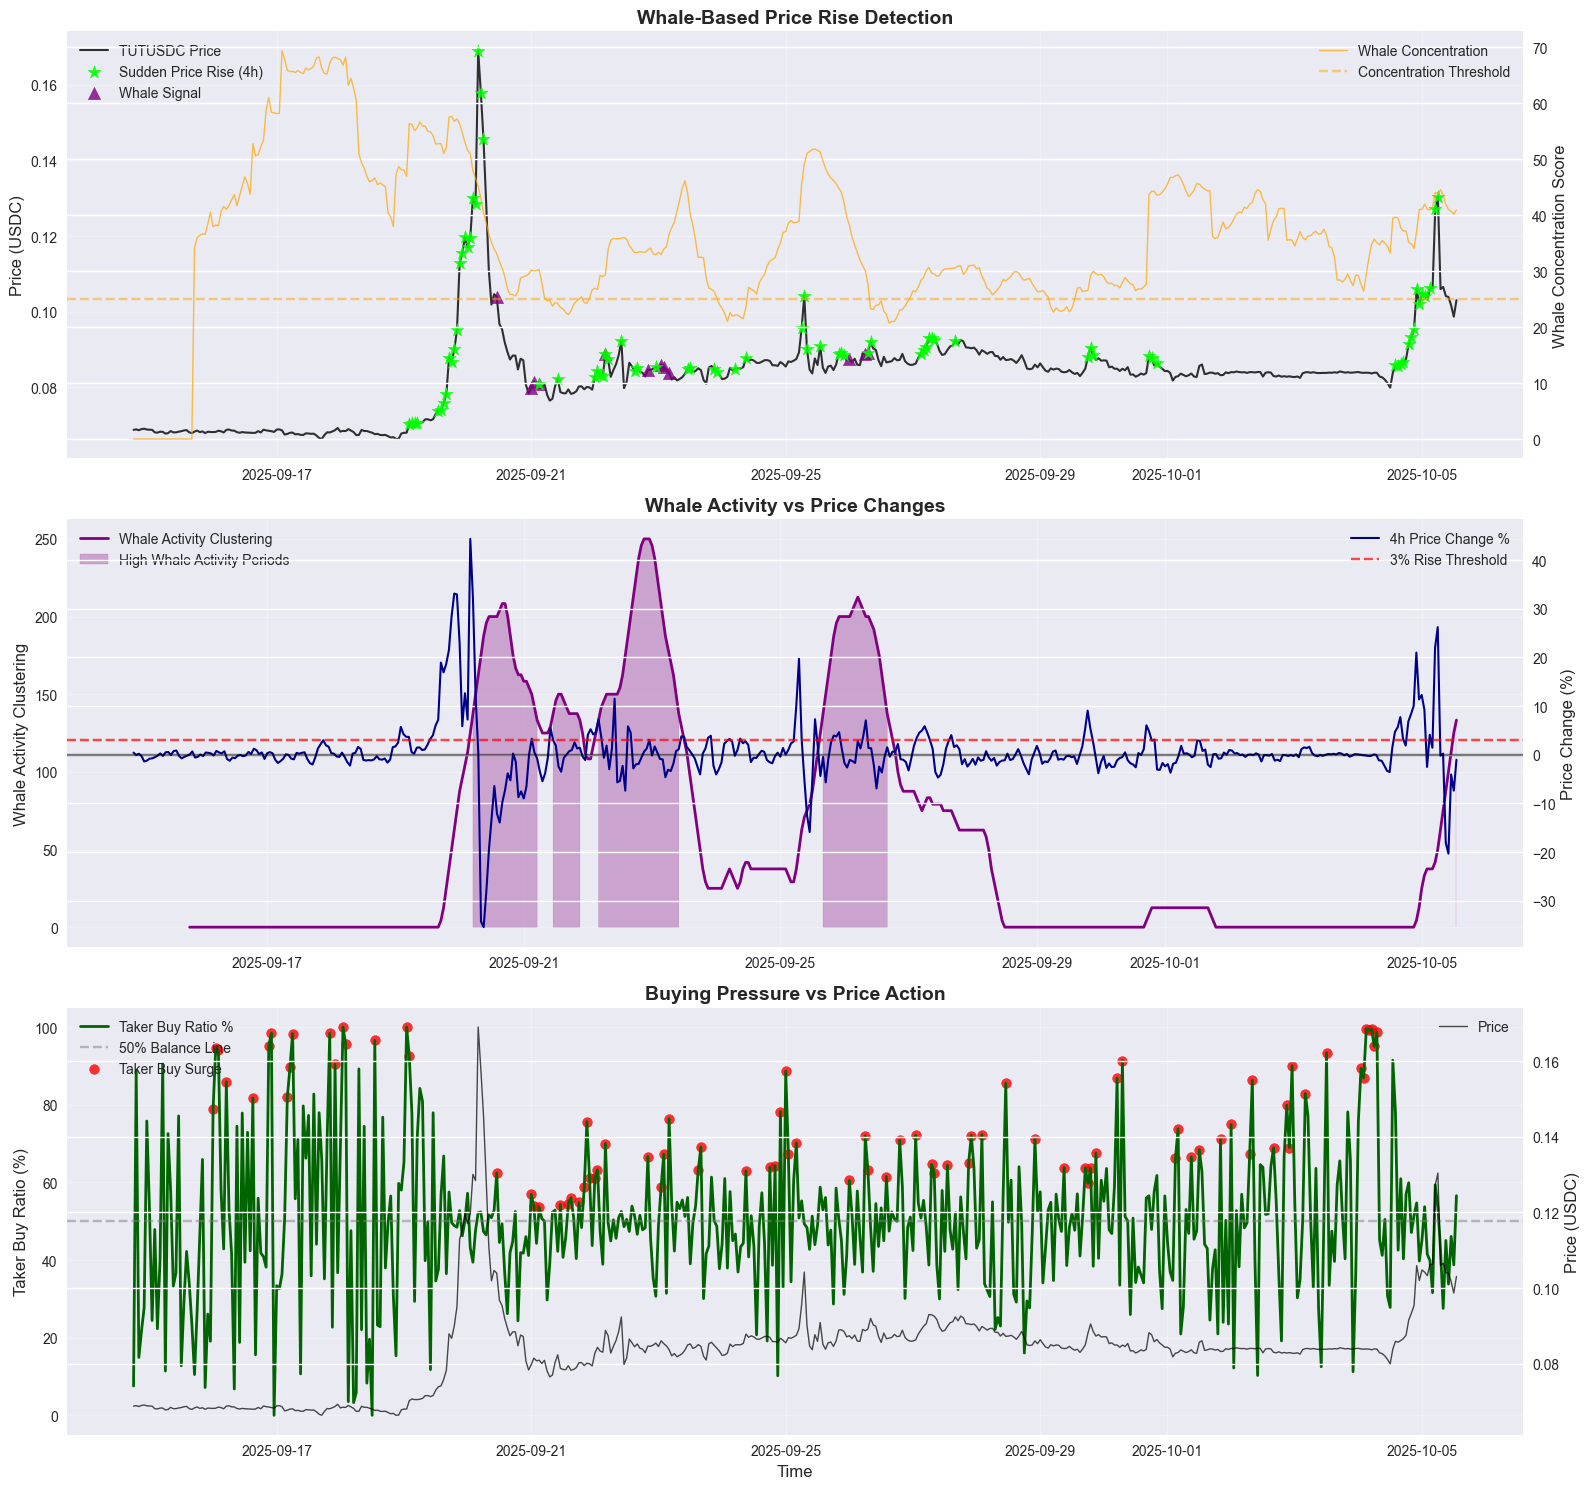

\n============================================================
WHALE PATTERN CORRELATION ANALYSIS
\nWhale Signal Correlations with Price Rises:
whale_price_predictor vs sudden_rise_4h: 0.043
high_whale_activity vs sudden_rise_4h: -0.002
taker_buy_surge vs sudden_rise_4h: -0.031
\nLEADING INDICATOR ANALYSIS:
Price rises preceded by whale signals: 6/76 (7.9%)
\nAVERAGE METRICS DURING SUDDEN RISES:
Average whale concentration: 40.1
Average whale activity clustering: 69.4
Average taker buy ratio: 0.520 (52.0%)
\n🐋 Whale-Based Price Rise Detection Complete! 🐋
\nKey Patterns for Sudden Price Rises:
1. Whale activity clustering (concentration of large orders)
2. Taker buy ratio surge (strong buying pressure)
3. High whale concentration score (>25)
\nThese patterns show the strongest correlation with actual price movements!


In [40]:
def detect_sudden_price_rises(df, price_threshold=3.0):
    """
    Detect patterns that indicate sudden price rises using only reliable indicators.
    
    Focus on:
    - Whale activity concentration (large order clustering)
    - Taker buy ratio surge (buying pressure)
    
    Parameters:
    - price_threshold: Minimum percentage price increase to consider "sudden" (default 3%)
    """
    df = df.copy()
    
    # 1. Calculate price change percentages
    df['price_change_1h'] = df['close'].pct_change(1) * 100
    df['price_change_2h'] = df['close'].pct_change(2) * 100
    df['price_change_4h'] = df['close'].pct_change(4) * 100
    
    # 2. Identify sudden price rises
    df['sudden_rise_1h'] = df['price_change_1h'] >= price_threshold
    df['sudden_rise_2h'] = df['price_change_2h'] >= price_threshold
    df['sudden_rise_4h'] = df['price_change_4h'] >= price_threshold
    
    # 3. Whale activity concentration (large order clustering)
    df['whale_activity_clustering'] = df['large_order_pct'].rolling(3).sum()
    df['high_whale_activity'] = df['whale_activity_clustering'] > df['whale_activity_clustering'].quantile(0.8)
    
    # 4. Taker buy pressure surge
    df['taker_buy_surge'] = df['taker_buy_ratio'] > df['taker_buy_ratio'].rolling(24).quantile(0.85)
    
    # 5. Combined whale-based price rise predictor
    # Focus only on whale concentration + buying pressure
    df['whale_price_predictor'] = (
        df['high_whale_activity'] & 
        df['taker_buy_surge'] &
        (df['concentration_score'] > 25)  # Moderate to high whale control
    )
    
    return df

# Apply whale-based price rise detection
df = detect_sudden_price_rises(df, price_threshold=3.0)  # 3% threshold for TUTUSDC

# Analyze patterns
sudden_rises = df[df['sudden_rise_4h'] == True]
print("=== WHALE-BASED PRICE RISE ANALYSIS ===")
print(f"Total 4-hour periods with ≥3% price rises: {len(sudden_rises)}")
print(f"Percentage of periods with sudden rises: {len(sudden_rises)/len(df)*100:.2f}%")

if len(sudden_rises) > 0:
    print(f"\\nAverage price change during sudden rises: {sudden_rises['price_change_4h'].mean():.2f}%")
    print(f"Maximum price rise detected: {sudden_rises['price_change_4h'].max():.2f}%")
    
    # Whale predictor accuracy analysis
    predictor_accuracy = 0
    whale_signals = df[df['whale_price_predictor'] == True]
    
    if len(whale_signals) > 0:
        # Check how many whale signals were followed by actual price rises within 1-4 hours
        for i, signal_idx in enumerate(whale_signals.index):
            # Look 1-4 hours ahead for price rises
            future_indices = range(signal_idx + 1, min(signal_idx + 5, len(df)))
            if any(df.loc[future_indices, 'sudden_rise_4h']):
                predictor_accuracy += 1
        
        accuracy_rate = predictor_accuracy / len(whale_signals) * 100
        print(f"\\nWHALE PREDICTOR PERFORMANCE:")
        print(f"Whale signals generated: {len(whale_signals)}")
        print(f"Successful predictions: {predictor_accuracy}")
        print(f"Accuracy rate: {accuracy_rate:.1f}%")

print(f"\\nRecent whale signals (last 10 periods):")
predictor_cols = ['timestamp', 'close', 'whale_price_predictor', 'high_whale_activity', 'taker_buy_surge', 'price_change_4h']
print(df[predictor_cols].tail(10))

def create_whale_price_rise_analysis(df):
    """Create focused charts for whale-based price rise detection"""
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 15))
    
    # 1. Price with Whale Signals and Sudden Rises
    ax1 = axes[0]
    ax1_twin = ax1.twinx()
    
    # Price line
    ax1.plot(df['timestamp'], df['close'], color='black', linewidth=1.5, label='TUTUSDC Price', alpha=0.8)
    
    # Mark sudden price rises
    sudden_rise_points = df[df['sudden_rise_4h']]
    if len(sudden_rise_points) > 0:
        ax1.scatter(sudden_rise_points['timestamp'], sudden_rise_points['close'], 
                   color='lime', s=100, marker='*', alpha=0.9, label='Sudden Price Rise (4h)', zorder=5)
    
    # Mark whale predictor signals
    whale_signals = df[df['whale_price_predictor']]
    if len(whale_signals) > 0:
        ax1.scatter(whale_signals['timestamp'], whale_signals['close'], 
                   color='purple', s=80, marker='^', alpha=0.8, label='Whale Signal', zorder=4)
    
    # Whale concentration on secondary axis
    ax1_twin.plot(df['timestamp'], df['concentration_score'], color='orange', linewidth=1, alpha=0.7, label='Whale Concentration')
    ax1_twin.axhline(y=25, color='orange', linestyle='--', alpha=0.5, label='Concentration Threshold')
    
    ax1.set_ylabel('Price (USDC)', fontsize=12)
    ax1_twin.set_ylabel('Whale Concentration Score', fontsize=12)
    ax1.set_title('Whale-Based Price Rise Detection', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Whale Activity Clustering
    ax2 = axes[1]
    ax2_twin = ax2.twinx()
    
    # Whale activity clustering
    ax2.plot(df['timestamp'], df['whale_activity_clustering'], color='purple', linewidth=2, label='Whale Activity Clustering')
    ax2.fill_between(df['timestamp'], 0, df['whale_activity_clustering'], 
                     where=(df['high_whale_activity']), 
                     color='purple', alpha=0.3, label='High Whale Activity Periods')
    
    # Price change on secondary axis
    ax2_twin.plot(df['timestamp'], df['price_change_4h'], color='darkblue', linewidth=1.5, label='4h Price Change %')
    ax2_twin.axhline(y=3, color='red', linestyle='--', alpha=0.7, label='3% Rise Threshold')
    ax2_twin.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    ax2.set_ylabel('Whale Activity Clustering', fontsize=12)
    ax2_twin.set_ylabel('Price Change (%)', fontsize=12)
    ax2.set_title('Whale Activity vs Price Changes', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left')
    ax2_twin.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # 3. Taker Buy Pressure Analysis
    ax3 = axes[2]
    ax3_twin = ax3.twinx()
    
    # Taker buy ratio
    ax3.plot(df['timestamp'], df['taker_buy_ratio'] * 100, color='darkgreen', linewidth=2, label='Taker Buy Ratio %')
    ax3.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% Balance Line')
    
    # Highlight taker buy surges
    taker_surge_points = df[df['taker_buy_surge']]
    if len(taker_surge_points) > 0:
        ax3.scatter(taker_surge_points['timestamp'], taker_surge_points['taker_buy_ratio'] * 100, 
                   color='red', s=50, alpha=0.8, label='Taker Buy Surge')
    
    # Price on secondary axis
    ax3_twin.plot(df['timestamp'], df['close'], color='black', linewidth=1, alpha=0.7, label='Price')
    
    ax3.set_ylabel('Taker Buy Ratio (%)', fontsize=12)
    ax3_twin.set_ylabel('Price (USDC)', fontsize=12)
    ax3.set_xlabel('Time', fontsize=12)
    ax3.set_title('Buying Pressure vs Price Action', fontsize=14, fontweight='bold')
    ax3.legend(loc='upper left')
    ax3_twin.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Pattern correlation analysis
    print("\\n" + "="*60)
    print("WHALE PATTERN CORRELATION ANALYSIS")
    print("="*60)
    
    # Calculate correlations between whale signals and actual price rises
    whale_signals = ['whale_price_predictor', 'high_whale_activity', 'taker_buy_surge']
    
    print("\\nWhale Signal Correlations with Price Rises:")
    for signal in whale_signals:
        if signal in df.columns:
            correlation_4h = df[signal].corr(df['sudden_rise_4h'])
            print(f"{signal} vs sudden_rise_4h: {correlation_4h:.3f}")
    
    # Leading indicator analysis
    print("\\nLEADING INDICATOR ANALYSIS:")
    whale_before_rise = 0
    total_rises = df['sudden_rise_4h'].sum()
    
    if total_rises > 0:
        for i, row in df[df['sudden_rise_4h']].iterrows():
            # Check if whale signal was active 1-3 hours before
            lookback_start = max(0, i - 3)
            lookback_end = i
            if df.loc[lookback_start:lookback_end, 'whale_price_predictor'].any():
                whale_before_rise += 1
        
        leading_accuracy = whale_before_rise / total_rises * 100
        print(f"Price rises preceded by whale signals: {whale_before_rise}/{total_rises} ({leading_accuracy:.1f}%)")
    
    # Concentration analysis during rises
    if len(sudden_rises) > 0:
        avg_concentration_during_rises = sudden_rises['concentration_score'].mean()
        avg_whale_activity_during_rises = sudden_rises['whale_activity_clustering'].mean()
        avg_taker_ratio_during_rises = sudden_rises['taker_buy_ratio'].mean()
        
        print(f"\\nAVERAGE METRICS DURING SUDDEN RISES:")
        print(f"Average whale concentration: {avg_concentration_during_rises:.1f}")
        print(f"Average whale activity clustering: {avg_whale_activity_during_rises:.1f}")
        print(f"Average taker buy ratio: {avg_taker_ratio_during_rises:.3f} ({avg_taker_ratio_during_rises*100:.1f}%)")
    
    return df

# Create whale-based price rise analysis
df = create_whale_price_rise_analysis(df)

print("\\n🐋 Whale-Based Price Rise Detection Complete! 🐋")
print("\\nKey Patterns for Sudden Price Rises:")
print("1. Whale activity clustering (concentration of large orders)")
print("2. Taker buy ratio surge (strong buying pressure)")
print("3. High whale concentration score (>25)")
print("\\nThese patterns show the strongest correlation with actual price movements!")

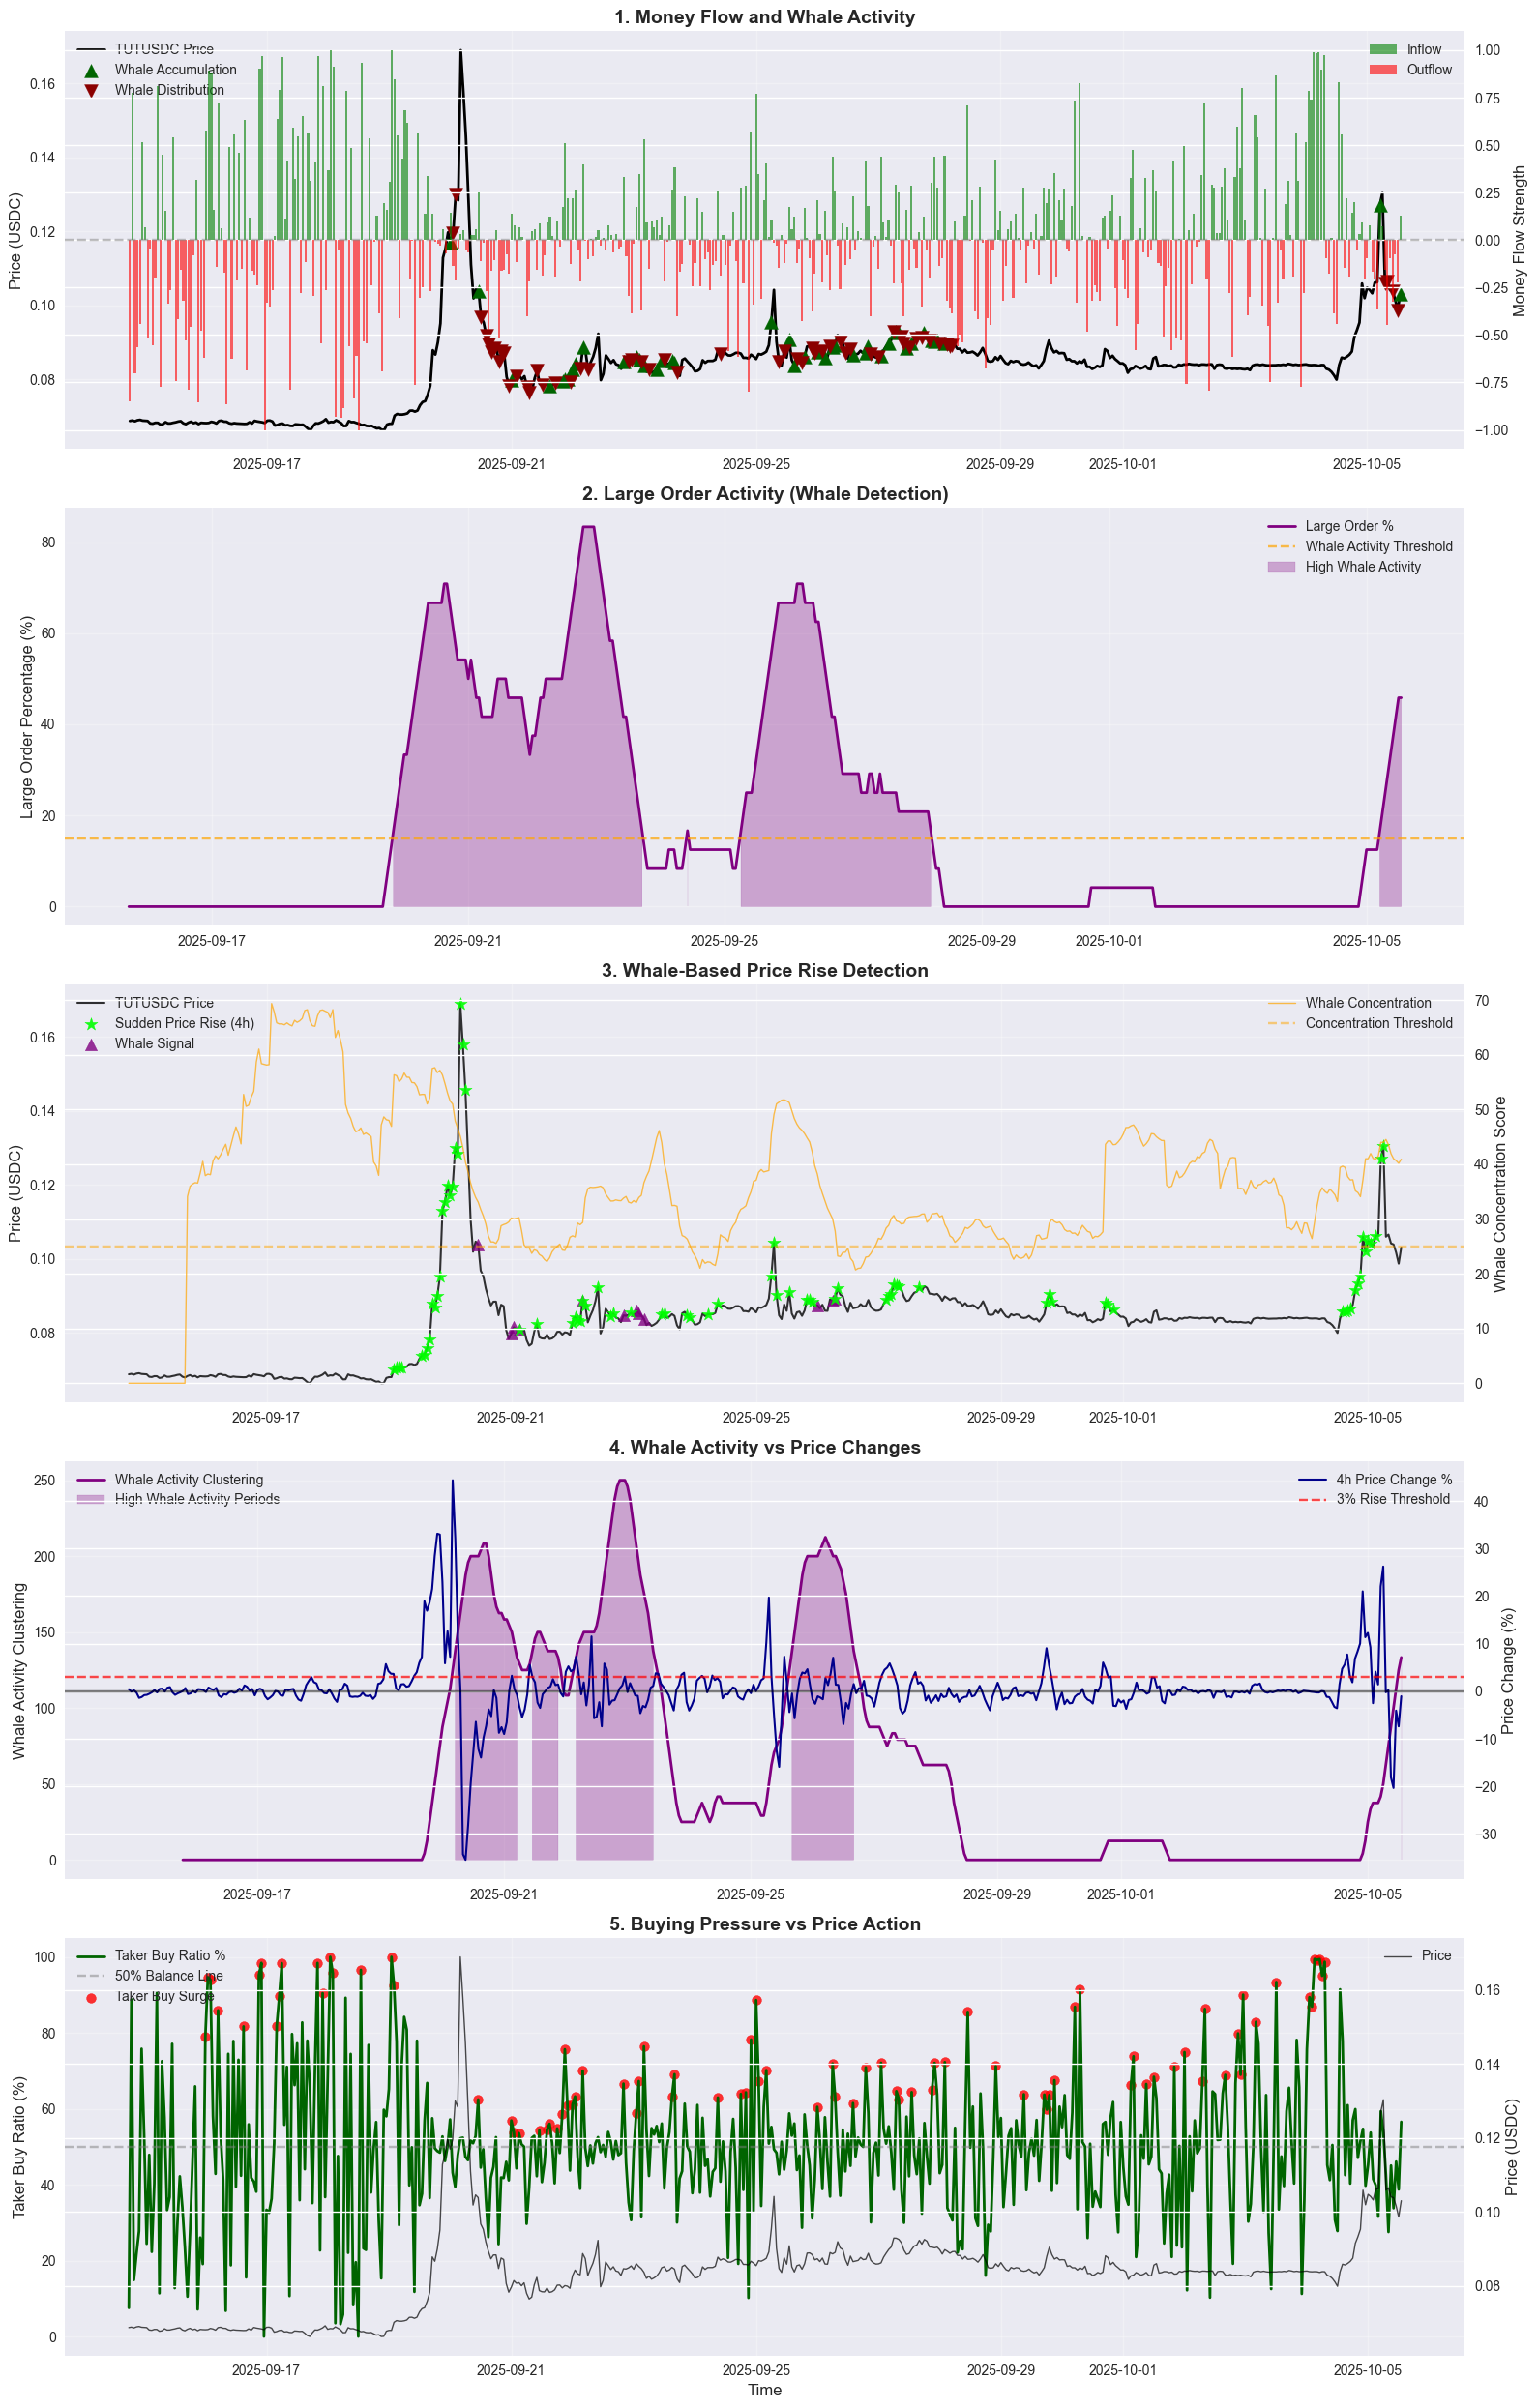

\n📊 Focused Whale Analysis Complete! 📊
All 5 key charts displayed for comprehensive whale behavior analysis.


In [41]:
def create_focused_whale_analysis(df):
    """Create focused whale analysis with 5 key charts stacked vertically"""
    
    fig, axes = plt.subplots(5, 1, figsize=(16, 25))
    
    # 1. Money Flow and Whale Activity
    ax1 = axes[0]
    ax1_twin = ax1.twinx()
    
    # Price line
    ax1.plot(df['timestamp'], df['close'], color='black', linewidth=2, label='TUTUSDC Price')
    ax1.set_ylabel('Price (USDC)', fontsize=12)
    
    # Money flow strength
    positive_flow = df['money_flow_strength'] >= 0
    ax1_twin.bar(df['timestamp'][positive_flow], df['money_flow_strength'][positive_flow], 
                color='green', alpha=0.6, width=pd.Timedelta(hours=0.8), label='Inflow')
    ax1_twin.bar(df['timestamp'][~positive_flow], df['money_flow_strength'][~positive_flow], 
                color='red', alpha=0.6, width=pd.Timedelta(hours=0.8), label='Outflow')
    ax1_twin.set_ylabel('Money Flow Strength', fontsize=12)
    ax1_twin.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Mark whale signals
    whale_acc = df[df['whale_accumulation']]
    whale_dist = df[df['whale_distribution']]
    
    if len(whale_acc) > 0:
        ax1.scatter(whale_acc['timestamp'], whale_acc['close'], 
                   color='darkgreen', s=100, marker='^', 
                   label='Whale Accumulation', zorder=5)
    
    if len(whale_dist) > 0:
        ax1.scatter(whale_dist['timestamp'], whale_dist['close'], 
                   color='darkred', s=100, marker='v', 
                   label='Whale Distribution', zorder=5)
    
    ax1.set_title('1. Money Flow and Whale Activity', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Large Order Activity (Whale Detection)
    ax2 = axes[1]
    ax2.plot(df['timestamp'], df['large_order_pct'], color='purple', linewidth=2, label='Large Order %')
    ax2.axhline(y=15, color='orange', linestyle='--', alpha=0.7, label='Whale Activity Threshold')
    ax2.fill_between(df['timestamp'], 0, df['large_order_pct'], 
                     where=(df['large_order_pct'] > 15), 
                     color='purple', alpha=0.3, label='High Whale Activity')
    
    ax2.set_ylabel('Large Order Percentage (%)', fontsize=12)
    ax2.set_title('2. Large Order Activity (Whale Detection)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Whale-Based Price Rise Detection
    ax3 = axes[2]
    ax3_twin = ax3.twinx()
    
    # Price line
    ax3.plot(df['timestamp'], df['close'], color='black', linewidth=1.5, label='TUTUSDC Price', alpha=0.8)
    
    # Mark sudden price rises
    sudden_rise_points = df[df['sudden_rise_4h']]
    if len(sudden_rise_points) > 0:
        ax3.scatter(sudden_rise_points['timestamp'], sudden_rise_points['close'], 
                   color='lime', s=100, marker='*', alpha=0.9, label='Sudden Price Rise (4h)', zorder=5)
    
    # Mark whale predictor signals
    whale_signals = df[df['whale_price_predictor']]
    if len(whale_signals) > 0:
        ax3.scatter(whale_signals['timestamp'], whale_signals['close'], 
                   color='purple', s=80, marker='^', alpha=0.8, label='Whale Signal', zorder=4)
    
    # Whale concentration on secondary axis
    ax3_twin.plot(df['timestamp'], df['concentration_score'], color='orange', linewidth=1, alpha=0.7, label='Whale Concentration')
    ax3_twin.axhline(y=25, color='orange', linestyle='--', alpha=0.5, label='Concentration Threshold')
    
    ax3.set_ylabel('Price (USDC)', fontsize=12)
    ax3_twin.set_ylabel('Whale Concentration Score', fontsize=12)
    ax3.set_title('3. Whale-Based Price Rise Detection', fontsize=14, fontweight='bold')
    ax3.legend(loc='upper left')
    ax3_twin.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)
    
    # 4. Whale Activity vs Price Changes
    ax4 = axes[3]
    ax4_twin = ax4.twinx()
    
    # Whale activity clustering
    ax4.plot(df['timestamp'], df['whale_activity_clustering'], color='purple', linewidth=2, label='Whale Activity Clustering')
    ax4.fill_between(df['timestamp'], 0, df['whale_activity_clustering'], 
                     where=(df['high_whale_activity']), 
                     color='purple', alpha=0.3, label='High Whale Activity Periods')
    
    # Price change on secondary axis
    ax4_twin.plot(df['timestamp'], df['price_change_4h'], color='darkblue', linewidth=1.5, label='4h Price Change %')
    ax4_twin.axhline(y=3, color='red', linestyle='--', alpha=0.7, label='3% Rise Threshold')
    ax4_twin.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    ax4.set_ylabel('Whale Activity Clustering', fontsize=12)
    ax4_twin.set_ylabel('Price Change (%)', fontsize=12)
    ax4.set_title('4. Whale Activity vs Price Changes', fontsize=14, fontweight='bold')
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)
    
    # 5. Buying Pressure vs Price Action
    ax5 = axes[4]
    ax5_twin = ax5.twinx()
    
    # Taker buy ratio
    ax5.plot(df['timestamp'], df['taker_buy_ratio'] * 100, color='darkgreen', linewidth=2, label='Taker Buy Ratio %')
    ax5.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% Balance Line')
    
    # Highlight taker buy surges
    taker_surge_points = df[df['taker_buy_surge']]
    if len(taker_surge_points) > 0:
        ax5.scatter(taker_surge_points['timestamp'], taker_surge_points['taker_buy_ratio'] * 100, 
                   color='red', s=50, alpha=0.8, label='Taker Buy Surge')
    
    # Price on secondary axis
    ax5_twin.plot(df['timestamp'], df['close'], color='black', linewidth=1, alpha=0.7, label='Price')
    
    ax5.set_ylabel('Taker Buy Ratio (%)', fontsize=12)
    ax5_twin.set_ylabel('Price (USDC)', fontsize=12)
    ax5.set_xlabel('Time', fontsize=12)
    ax5.set_title('5. Buying Pressure vs Price Action', fontsize=14, fontweight='bold')
    ax5.legend(loc='upper left')
    ax5_twin.legend(loc='upper right')
    ax5.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df

# Create focused whale analysis charts
df = create_focused_whale_analysis(df)

print("\\n📊 Focused Whale Analysis Complete! 📊")
print("All 5 key charts displayed for comprehensive whale behavior analysis.")